In [ ]:
# Previous notebook execution 
%run "./1.7 Univariate Analysis (Numerical Column Analysis).ipynb"

## 1.9 Countplot with Hue
Countplot আমরা আগে শিখেছি এটি একটি categorical variable-এর প্রতিটি category কতবার আছে তা bar দিয়ে দেখায়। কিন্তু শুধু count দেখলে অনেক সময় আসল গল্পটা বোঝা যায় না। যেমন Titanic-এ মোট কতজন male আর female ছিল সেটা জানা যায়, কিন্তু তাদের মধ্যে কতজন survive করেছে সেটা জানা যায় না। এই সমস্যার সমাধান হলো `hue` parameter – যা একটি তৃতীয় categorical variable color দিয়ে plot-এ যোগ করে।

### What is Hue?
`hue` parameter একটি categorical column নেয় এবং সেই column-এর প্রতিটি unique value-এর জন্য আলাদা color ব্যবহার করে। এতে একটি plot-এই দুটি categorical variable-এর মধ্যে সম্পর্ক একসাথে দেখা যায়।

উদাহরণ হিসেবে ভাবো- x-axis-এ Sex (male/female), আর hue-তে Survived (yes/no)। এতে প্রতিটি gender-এর জন্য দুটো bar দেখাবে - একটি যারা survive করেছে, একটি যারা করেনি।
### Example 1: Sex vs Survived


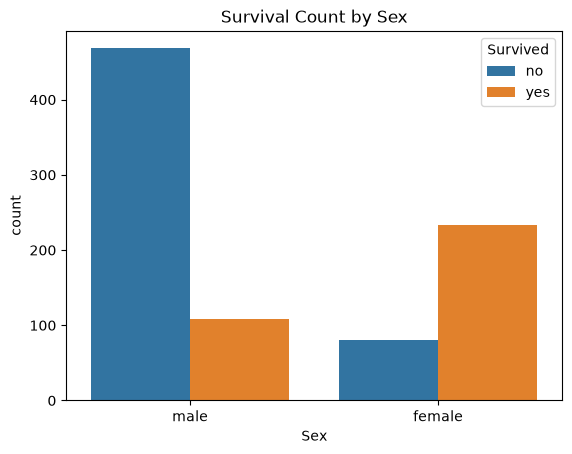

In [6]:
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title('Survival Count by Sex')
plt.show()

এই plot থেকে আমরা দেখতে পাই female passengers-এর মধ্যে survive করার হার অনেক বেশি ছিল male-দের তুলনায়। শুধু countplot দিয়ে এই comparison সম্ভব হতো না।

groupby দিয়ে exact percentage বের করা যায়:

In [10]:
gender_split = df.groupby('Sex') ['Survived'].value_counts (normalize=True)
print(gender_split)

Sex     Survived
female  yes         0.742038
        no          0.257962
male    no          0.811092
        yes         0.188908
Name: proportion, dtype: float64


normalize = True দিলে count-এর বদলে proportion (0 থেকে 1) দেখায়। এতে বোঝা যায় female-দের মধ্যে কত % survive করেছে এবং male-দের মধ্যে কত % করেছে।

### Example 2: Pclass vs Survived

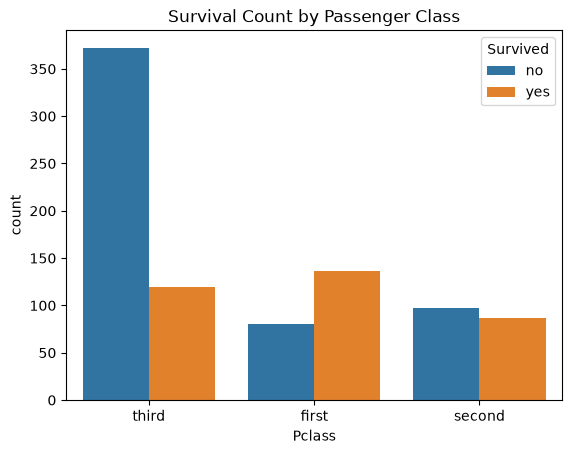

In [12]:
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title('Survival Count by Passenger Class')
plt.show()

এই plot থেকে দেখা যায় first class passengers সবচেয়ে বেশি survive করেছে এবং third class সবচেয়ে কম। Passenger class এবং survival-এর মধ্যে একটি স্পষ্ট pattern আছে।


In [13]:
pclass_split = df.groupby('Pclass')['Survived'].value_counts(normalize=True)
print(pclass_split)

Pclass  Survived
first   yes         0.629630
        no          0.370370
second  no          0.527174
        yes         0.472826
third   no          0.757637
        yes         0.242363
Name: proportion, dtype: float64


### When to Use Countplot with Hue?
Countplot with Hue তখনই use করবো যখন:
- দুটো categorical variable-এর মধ্যে সম্পর্ক দেখতে চাই
- একটি category-র মধ্যে আরেকটি category-র distribution জানতে চাই
- Groups-এর মধ্যে frequency compare করতে চাই
### Summary
`hue` parameter Countplot-কে Bivariate থেকে Multivariate-এ নিয়ে যায়। Titanic data-তে আমরা দেখলাম Sex এবং Pclass উভয়ই Survival-এর সাথে সম্পর্কিত এবং এই সম্পর্ক Countplot with Hue ছাড়া এত সহজে বোঝা সম্ভব হতো না।
`groupby` দিয়ে exact proportion বের করে plot-এর insight verify করা যায়।